# Context


**Canonical model:** Kuramoto coupled oscillators.

**Modelling practice:** Individual heterogeneity.

**Why it matters:** An apparent collective threshold can depend on who is in the population and how large that population is.

**How it appears here:** Frequency distributions and finite oscillator populations are varied while coherence and the apparent onset of synchronisation are measured.

By the end, you should be able to explain how the distribution of individual frequencies and finite population size alter the observed onset of collective synchronisation.



Earlier workshops supplied several extensions labelled A–D. From this week, some of that scaffolding is removed. As you begin planning your project, you should increasingly decide what to change, what to keep fixed and what evidence would answer your question. This workshop still provides several possible directions, but it does not turn each one into a complete investigation for you.

This notebook needs Python 3.10 or later, NumPy, Matplotlib, and IPython. It is self-contained and does not require the lecture repository or separate files. Run the cells in order from a fresh kernel.

> **While developing:** set `QUICK_RUN = True` in the setup cell. Long sweeps then use fewer oscillators, fewer parameter values, fewer repeated runs and shorter simulations. This is useful for checking that code works, but switch back to `False` before drawing conclusions or reporting results. Progress bars report progress across conditions rather than every numerical time step.


In [18]:
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

SEED = 3024
INK = "#1B2A4C"
BLUE = "#5879AA"
YELLOW = "#EDCC55"
ORANGE = "#DF6338"

# Keep this False for figures or results you intend to report. Set it to
# True while testing code or exploring an idea quickly.
QUICK_RUN = False


def choose(full_value, quick_value):
    return quick_value if QUICK_RUN else full_value


def show_animation(anim):
    """Render a standard Matplotlib animation with playback controls."""
    plt.close(anim._fig)
    no_reverse = "<style>input[value='reflect'], input[value='reflect'] + label {display:none!important}</style>"
    return HTML(no_reverse + anim.to_jshtml(default_mode="once"))


mode = "quick exploratory run" if QUICK_RUN else "full run"
print(f"NumPy {np.__version__} · seed {SEED} · {mode}")


NumPy 2.4.2 · seed 3024 · full run


# Specify the model


## Begin with uncoupled oscillators
For $\dot\theta_i=\omega_i$, forward Euler gives

$$
\theta_i^{n+1}=\theta_i^n+\Delta t\,\omega_i \pmod{2\pi}.
$$

Because the derivative is constant, this numerical update agrees with the exact solution at the sampled times.


In [19]:
def wrap_phase(phases: np.ndarray) -> np.ndarray:
    """Wrap phases into [-pi, pi)."""
    return (np.asarray(phases, dtype=float) + np.pi) % (2 * np.pi) - np.pi


def uncoupled_step(phases: np.ndarray, frequencies: np.ndarray, dt: float) -> np.ndarray:
    phases = np.asarray(phases, dtype=float)
    frequencies = np.asarray(frequencies, dtype=float)
    if phases.shape != frequencies.shape:
        raise ValueError("phases and frequencies must have the same shape")
    if dt <= 0:
        raise ValueError("dt must be positive")
    return wrap_phase(phases + dt * frequencies)


phases = np.array([0.0, 0.0])
frequencies = np.array([1.0, 1.3])
assert np.allclose(uncoupled_step(phases, frequencies, 0.1), [0.1, 0.13])
print("Uncoupled update test passed.")


Uncoupled update test passed.


## Specify the Kuramoto model
| Ingredient | Workshop choice |
|---|---|
| Oscillator state | phase $\theta_i$ |
| Internal dynamics | fixed natural frequency $\omega_i$ |
| Network | equally weighted complete graph |
| Interaction | $\sin(\theta_j-\theta_i)$ |
| Control parameter | coupling strength $K$ |
| Numerical update | synchronous forward Euler |
| Time step | $\Delta t=0.02$ unless deliberately varied |
| Observable | coherence $r$ |

> **Modelling choice:** The frequency distribution, coupling function, network, timestep, and initial phases are separate choices.

Kuramoto analyses often centre the natural-frequency distribution at zero. This means working in a coordinate frame that rotates at the population's mean frequency, so negative values describe oscillators falling backwards relative to that frame. They need not be physically rotating backwards. Adding the same constant $\Omega$ to every $\omega_i$ makes the whole population rotate together without changing any phase differences or the coherence $r$. The animation below uses a positive mean frequency and coupling above the onset of collective locking so that the oscillators continue around the circle while their phases organise. Frame $n$ represents time $t_n=n\Delta t$; the frame number is not itself the simulation time. Frame $n$ represents time $t_n=n\Delta t$; the frame number is not itself the simulation time. Frame $n$ represents time $t_n=n\Delta t$; the frame number is not itself the simulation time.


## Express the population as an array update

```text
INPUT phases theta[1..N], natural frequencies omega[1..N]
INPUT coupling K, time step delta_t, number of steps T

FOR each time step:
    FOR each oscillator i:
        coupling_i <- (K / N) * SUM_j SIN(theta[j] - theta[i])
        phase_rate[i] <- omega[i] + coupling_i
    theta <- theta + delta_t * phase_rate
    theta <- theta MODULO 2*pi
    coherence <- ABS(MEAN(EXP(I * theta)))

RETURN phases and coherence history
```

Keeping `omega` separate from `phase_rate` makes the intrinsic heterogeneity explicit.


In [20]:
@dataclass(frozen=True)
class KuramotoParameters:
    n_oscillators: int = 80
    coupling: float = 3.2
    dt: float = 0.02
    frequency_mean: float = 3.0
    frequency_sd: float = 1.0

    def __post_init__(self):
        if self.n_oscillators < 1:
            raise ValueError("n_oscillators must be positive")
        if self.dt <= 0 or self.frequency_sd < 0 or self.coupling < 0:
            raise ValueError("dt must be positive; frequency_sd and coupling cannot be negative")


def initialise_kuramoto(params: KuramotoParameters, rng: np.random.Generator):
    phases = rng.uniform(-np.pi, np.pi, params.n_oscillators)
    frequency_offsets = rng.normal(0.0, params.frequency_sd, params.n_oscillators)
    frequency_offsets -= frequency_offsets.mean()
    frequencies = params.frequency_mean + frequency_offsets
    return phases, frequencies


## Inspect the coupling term
For all-to-all coupling,

$$
C_i=\frac{1}{N}\sum_j\sin(\theta_j-\theta_i).
$$

> **Discuss:** What should $C_i$ be when all phases are identical? What sign should it have for an oscillator lagging just behind a coherent group?

> **Down the ladder:** test the local response before embedding it in a population trajectory.


In [21]:
def kuramoto_coupling(phases: np.ndarray) -> np.ndarray:
    """Return the all-to-all sinusoidal coupling experienced by each oscillator."""
    phases = np.asarray(phases, dtype=float)
    if phases.ndim != 1:
        raise ValueError("phases must be one-dimensional")
    order_parameter = np.mean(np.exp(1j * phases))
    return np.imag(order_parameter * np.exp(-1j * phases))


assert np.allclose(kuramoto_coupling(np.zeros(5)), 0.0)
opposite_pair = np.array([0.0, np.pi])
assert np.allclose(kuramoto_coupling(opposite_pair), 0.0, atol=1e-12)
print("Coupling tests passed.")


Coupling tests passed.


# Implement and test


## Apply one synchronous update
$$
\theta_i^{n+1}
=\theta_i^n+\Delta t\left[
\omega_i+K C_i(\boldsymbol\theta^n)
\right]\pmod{2\pi}.
$$

All coupling terms must be calculated from the same previous phase vector.


In [22]:
def kuramoto_step(
    phases: np.ndarray,
    frequencies: np.ndarray,
    params: KuramotoParameters,
) -> np.ndarray:
    phases = np.asarray(phases, dtype=float)
    frequencies = np.asarray(frequencies, dtype=float)
    if phases.shape != (params.n_oscillators,) or frequencies.shape != phases.shape:
        raise ValueError("state shapes do not match params.n_oscillators")
    derivative = frequencies + params.coupling * kuramoto_coupling(phases)
    return wrap_phase(phases + params.dt * derivative)


zero_coupling = KuramotoParameters(n_oscillators=3, coupling=0.0, dt=0.1)
test_phases = np.array([0.0, 0.2, -0.4])
test_frequencies = np.array([1.0, 0.0, -1.0])
assert np.allclose(
    kuramoto_step(test_phases, test_frequencies, zero_coupling),
    uncoupled_step(test_phases, test_frequencies, 0.1),
)
print("One-step limiting-case test passed.")


One-step limiting-case test passed.


# Simulate and inspect


**Numerical evolution:** calculate all phase rates from the current phases, then advance every phase by $\Delta t$ and wrap modulo $2\pi$. Rendering frames is separate from integration.


## Simulate and record
The natural frequencies remain fixed within one run. Only the phases evolve.


In [23]:
def simulate_kuramoto(
    params: KuramotoParameters, steps: int, seed: int,
    progress: bool = False, description: str = "Simulating",
):
    if not isinstance(steps, (int, np.integer)) or steps < 0:
        raise ValueError("steps must be a non-negative integer")
    rng = np.random.default_rng(seed)
    phases, frequencies = initialise_kuramoto(params, rng)
    history = np.empty((steps + 1, params.n_oscillators))
    history[0] = phases
    time_steps = range(1, steps + 1)
    if progress:
        time_steps = tqdm(time_steps, total=steps, desc=description, leave=False)
    for time in time_steps:
        phases = kuramoto_step(phases, frequencies, params)
        history[time] = phases
    return history, frequencies


baseline = KuramotoParameters()
phase_history, natural_frequencies = simulate_kuramoto(baseline, steps=500, seed=SEED)
print("history shape:", phase_history.shape)


history shape: (501, 80)


### Pause the process
A phase snapshot, a coherence curve and a phase-offset histogram show different aspects of the same stored run. The vertical marker keeps the summaries aligned with the current frame. The formal definition of $r$ comes next.

This animation uses Matplotlib's standard controls. That is enough for inspecting a model during a project: the important work is storing the states and updating the artists, not building a custom player.


In [24]:
def animate_kuramoto_run(history: np.ndarray, dt: float, highlight_index: int | None = None):
    # Keep adjacent displayed states close enough that the motion is visually continuous.
    frame_step = max(1, min(len(history) // 160, round(0.08 / dt)))
    frames = np.arange(0, len(history), frame_step)
    time = np.arange(len(history)) * dt
    order = np.mean(np.exp(1j * history), axis=1)
    coherence = np.abs(order)
    mean_phase = np.angle(order)

    fig = plt.figure(figsize=(8.0, 3.6), layout="constrained")
    grid = fig.add_gridspec(2, 2, width_ratios=(0.9, 1.25), hspace=0.42)
    phase_ax = fig.add_subplot(grid[:, 0])
    coherence_ax = fig.add_subplot(grid[0, 1])
    spread_ax = fig.add_subplot(grid[1, 1])

    phase_ax.set(title="Current phases", xlim=(-1.12, 1.12), ylim=(-1.12, 1.12), aspect="equal")
    phase_ax.axis("off")
    angle = np.linspace(0, 2 * np.pi, 300)
    phase_ax.plot(np.cos(angle), np.sin(angle), color=INK, lw=1.8)
    phase_points = phase_ax.scatter([], [], s=28, color="#4B93C3", edgecolor="white", lw=0.4, zorder=3)
    mean_vector, = phase_ax.plot([], [], color=ORANGE, lw=3)
    time_label = phase_ax.text(0, -1.08, "", ha="center", va="top", color=INK)

    coherence_ax.plot(time, coherence, color=BLUE, lw=2)
    coherence_marker = coherence_ax.axvline(0, color=ORANGE, lw=1.5)
    coherence_dot, = coherence_ax.plot([], [], "o", color=ORANGE, ms=5)
    coherence_ax.set(title="Coherence history", ylabel="$r(t)$", xlim=(time[0], time[-1]), ylim=(-0.03, 1.03))
    coherence_ax.grid(alpha=0.2)

    bins = np.linspace(-np.pi, np.pi, 19)
    centres = 0.5 * (bins[:-1] + bins[1:])
    bars = spread_ax.bar(centres, np.zeros(len(centres)), width=np.diff(bins), color="#8CB9D8", align="center")
    spread_ax.set(title="Phase offsets from the mean", xlabel="offset", ylabel="oscillators", xlim=(-np.pi, np.pi))
    spread_ax.set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", "0", r"$\pi$"])
    spread_ax.grid(axis="y", alpha=0.2)

    def update(frame):
        phases = history[frame]
        xy = np.column_stack((np.cos(phases), np.sin(phases)))
        phase_points.set_offsets(xy)
        colours = np.full(len(phases), "#4B93C3", dtype=object)
        sizes = np.full(len(phases), 28.0)
        if highlight_index is not None:
            colours[highlight_index] = YELLOW
            sizes[highlight_index] = 58
        phase_points.set_color(colours)
        phase_points.set_sizes(sizes)
        mean_vector.set_data([0, coherence[frame] * np.cos(mean_phase[frame])], [0, coherence[frame] * np.sin(mean_phase[frame])])
        time_label.set_text(f"$t={time[frame]:.1f}$")
        coherence_marker.set_xdata([time[frame], time[frame]])
        coherence_dot.set_data([time[frame]], [coherence[frame]])

        offsets = np.angle(np.exp(1j * (phases - mean_phase[frame])))
        counts, _ = np.histogram(offsets, bins=bins)
        for bar, count in zip(bars, counts):
            bar.set_height(count)
        spread_ax.set_ylim(0, max(2, counts.max() * 1.12))
        return phase_points, mean_vector, time_label, coherence_marker, coherence_dot, *bars

    anim = animation.FuncAnimation(fig, update, frames=frames, interval=90, blit=False)
    return anim


display(show_animation(animate_kuramoto_run(phase_history, baseline.dt)))


Here natural frequencies are centred at $3$ radians per unit time, so every oscillator advances in the same direction in the laboratory frame. Subtracting the population mean would give an equivalent co-rotating description centred at zero, but negative values there are relative drift, not literal backwards motion through space.


# Analyse


## Measure phase coherence
The coordinated display above used coherence before defining it. We now calculate the same quantity directly, together with the mean phase $\psi(t)$. The phase-offset histogram explains changes that $r(t)$ alone cannot: one tight cluster gives large $r$, while two tight clusters on opposite sides of the circle can cancel and give small $r$.

$$
r(t)e^{\mathrm{i}\psi(t)}
=\frac{1}{N}\sum_j e^{\mathrm{i}\theta_j(t)}.
$$


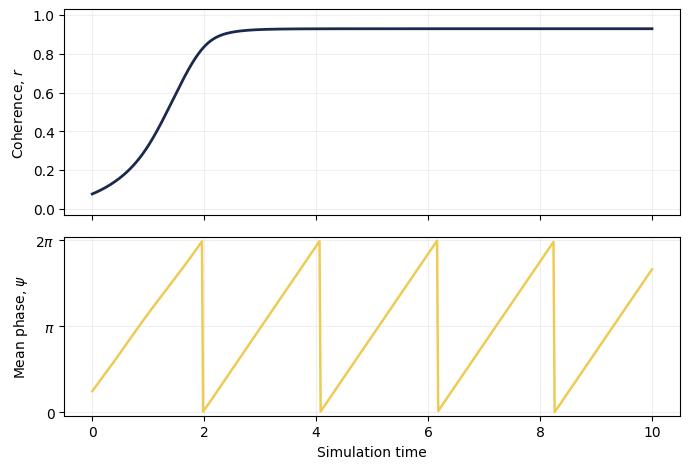

In [8]:
def coherence(phases: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return coherence magnitude r and mean phase psi."""
    phases = np.asarray(phases, dtype=float)
    if phases.ndim not in (1, 2):
        raise ValueError("phases must be one- or two-dimensional")
    order = np.mean(np.exp(1j * phases), axis=-1)
    return np.abs(order), np.angle(order)


r_history, psi_history = coherence(phase_history)
time = np.arange(len(r_history)) * baseline.dt
psi_periodic = np.mod(psi_history, 2 * np.pi)

fig, axes = plt.subplots(2, 1, figsize=(7, 4.8), sharex=True,
                         gridspec_kw={"height_ratios": [1.15, 1]})
axes[0].plot(time, r_history, color=INK, lw=2)
axes[0].set(ylabel="Coherence, $r$", ylim=(-0.03, 1.03))
axes[1].plot(time, psi_periodic, color=YELLOW, lw=1.8)
axes[1].set(xlabel="Simulation time", ylabel=r"Mean phase, $\psi$",
            ylim=(-0.12, 2 * np.pi + 0.12), yticks=[0, np.pi, 2 * np.pi],
            yticklabels=["0", r"$\pi$", r"$2\pi$"])
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## First sweep coupling strength
Use the same seed at every $K$. This paired sweep reveals how one sampled population responds as coupling increases.

> **Up the ladder over coupling:** replace separate conditions by a response curve showing how long-time coherence changes with coupling.


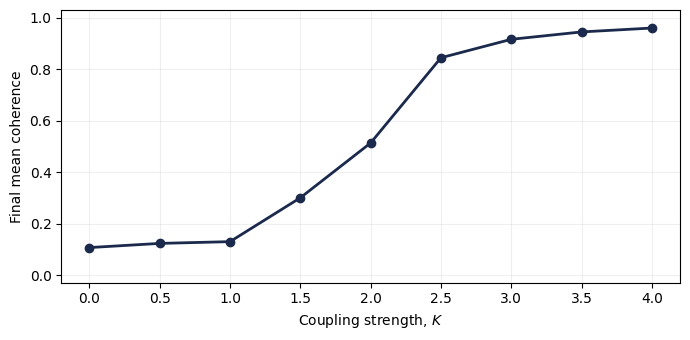

In [9]:
coupling_values = np.linspace(0, 4, choose(9, 5))
single_sweep_steps = choose(700, 320)
single_run_r = []
for coupling in tqdm(coupling_values, desc="Single-run coupling sweep"):
    params = KuramotoParameters(coupling=float(coupling))
    history, _ = simulate_kuramoto(params, steps=single_sweep_steps, seed=SEED)
    r, _ = coherence(history[-choose(150, 80):])
    single_run_r.append(r.mean())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coupling_values, single_run_r, "o-", color=INK, lw=2)
ax.set(xlabel="Coupling strength, $K$", ylabel="Final mean coherence", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## Then repeat each condition
Each run independently samples initial phases and natural frequencies. The band records run-to-run variation, not uncertainty from measurement error.


The plot below uses a mean line and a middle-50% band. That is one defensible choice, not a fixed recipe.

- Use mean and standard deviation for roughly symmetric outcomes.
- Use median and quartiles for skewed or outlier-prone outcomes.
- Use a wider quantile interval or the full range when tail behaviour is central to the question.

Whatever you choose, state the number of runs and define the band or error bars. For a small ensemble, keep the individual values visible as well.


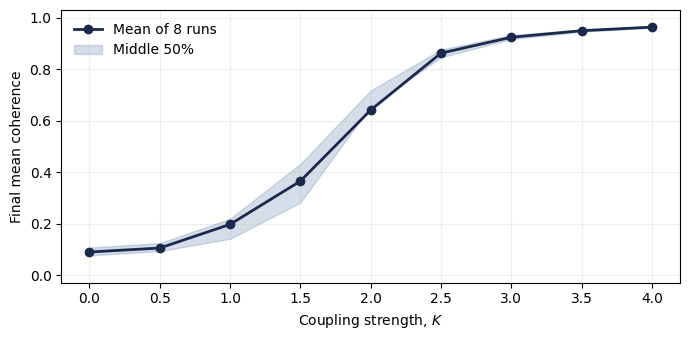

In [10]:
seeds = np.arange(choose(8, 3)) + SEED
ensemble_steps = choose(700, 350)
ensemble = np.empty((len(coupling_values), len(seeds)))
for row, coupling in enumerate(tqdm(coupling_values, desc="Ensemble over coupling")):
    params = KuramotoParameters(coupling=float(coupling))
    for column, seed in enumerate(seeds):
        history, _ = simulate_kuramoto(params, steps=ensemble_steps, seed=int(seed))
        r, _ = coherence(history[-choose(150, 80):])
        ensemble[row, column] = r.mean()

mean_r = ensemble.mean(axis=1)
lower, upper = np.quantile(ensemble, [0.25, 0.75], axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coupling_values, mean_r, "o-", color=INK, lw=2, label=f"Mean of {len(seeds)} runs")
ax.fill_between(coupling_values, lower, upper, color=BLUE, alpha=0.25, label="Middle 50%")
ax.set(xlabel="Coupling strength, $K$", ylabel="Final mean coherence", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## A compact toolkit for heterogeneity
Heterogeneity should be inspected at three levels:

1. **Inputs:** show the distribution assigned to the individuals. A histogram is a useful start; an empirical cumulative distribution is often better for comparing samples.
2. **Individuals:** relate each assigned value to its realised behaviour. Here we compare $\omega_i$ with $\omega_i^\infty$ and distinguish locked oscillators from drifters.
3. **Populations:** vary one property of the distribution across repeated runs, then report a collective response and its spread.

The next three analyses implement those views without changing the underlying simulation. The same pattern is reusable whenever agents differ in rates, thresholds, sensitivities or initial conditions.

### Widen the frequency distribution
The previous sweep changed the interaction strength. Now hold $K$, $N$, $\Delta t$, the network and the observation window fixed, and vary the natural-frequency standard deviation $\sigma_\omega$.

This isolates the modelling focus of the week. A change in collective behaviour can arise because the population became more heterogeneous even though no individual update rule changed.

> **Up the ladder through three summaries:** reduce $r(t)$ to one $r_\infty$ per run; combine repeated populations at fixed $\sigma_\omega$ into an ensemble summary; then abstract over $\sigma_\omega$ to obtain a heterogeneity-response curve.


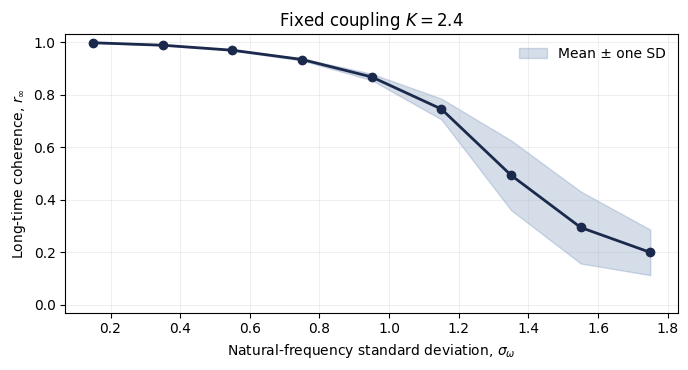

In [11]:
frequency_sds = np.linspace(0.15, 1.75, choose(9, 5))
width_seeds = np.arange(choose(8, 3)) + SEED
fixed_coupling = 2.4
width_results = np.empty((len(frequency_sds), len(width_seeds)))

for row, frequency_sd in enumerate(tqdm(frequency_sds, desc="Sweep frequency width")):
    for column, seed in enumerate(width_seeds):
        params = KuramotoParameters(
            n_oscillators=choose(180, 80),
            coupling=fixed_coupling,
            dt=0.02,
            frequency_mean=3.0,
            frequency_sd=float(frequency_sd),
        )
        history, _ = simulate_kuramoto(params, steps=choose(2600, 900), seed=int(seed))
        r, _ = coherence(history[-choose(400, 180):])
        width_results[row, column] = r.mean()

mean_width = width_results.mean(axis=1)
sd_width = width_results.std(axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(frequency_sds, mean_width, "o-", color=INK, lw=2)
ax.fill_between(
    frequency_sds,
    np.maximum(0, mean_width - sd_width),
    np.minimum(1, mean_width + sd_width),
    color=BLUE,
    alpha=0.25,
    label="Mean ± one SD",
)
ax.set(
    xlabel=r"Natural-frequency standard deviation, $\sigma_\omega$",
    ylabel=r"Long-time coherence, $r_\infty$",
    ylim=(-0.03, 1.03),
    title=rf"Fixed coupling $K={fixed_coupling}$",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


#### Change the shape of the distribution
Width is not the only form of heterogeneity. A bimodal population is different in kind, not merely broader: it contains two frequency groups. Compare it with narrow and broad unimodal populations while keeping the coupling rule, time step, seeds and observation window fixed.


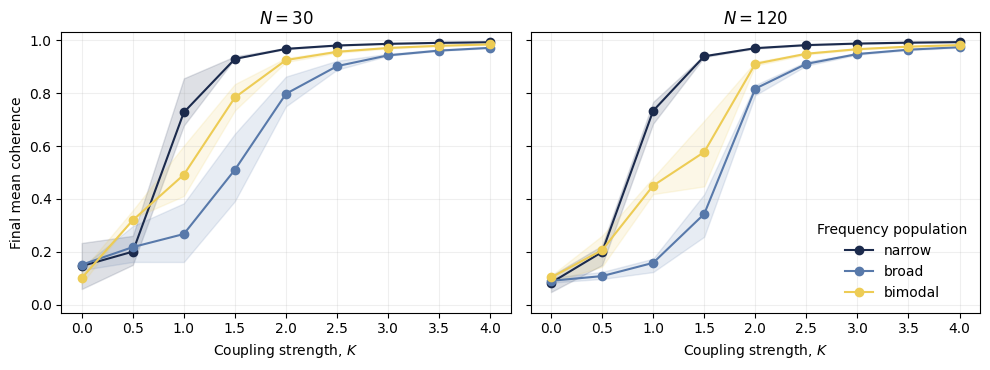

In [12]:
def sample_population(kind: str, n: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    phases = rng.uniform(-np.pi, np.pi, n)
    if kind == "narrow":
        frequencies = rng.normal(3.0, 0.45, n)
    elif kind == "broad":
        frequencies = rng.normal(3.0, 0.85, n)
    elif kind == "bimodal":
        groups = rng.choice([-1.0, 1.0], size=n)
        frequencies = 3.0 + 0.7 * groups + rng.normal(0.0, 0.22, n)
    else:
        raise ValueError("kind must be narrow, broad, or bimodal")
    frequencies += 3.0 - frequencies.mean()
    return phases, frequencies


def simulate_population(kind: str, n: int, coupling: float, steps: int, seed: int) -> np.ndarray:
    params = KuramotoParameters(n_oscillators=n, coupling=coupling)
    phases, frequencies = sample_population(kind, n, np.random.default_rng(seed))
    history = np.empty((steps + 1, n))
    history[0] = phases
    for time in range(1, steps + 1):
        order_parameter = np.exp(1j * phases).mean()
        coupling_term = np.imag(order_parameter * np.exp(-1j * phases))
        phases = wrap_phase(phases + params.dt * (frequencies + coupling * coupling_term))
        history[time] = phases
    return history


population_kinds = ("narrow", "broad", "bimodal")
population_sizes = (30, 120)
heterogeneity_seeds = np.arange(6) + SEED
heterogeneity = {}
for kind in tqdm(population_kinds, desc="Compare frequency populations"):
    for n in population_sizes:
        values = np.empty((len(coupling_values), len(heterogeneity_seeds)))
        for row, coupling in enumerate(coupling_values):
            for column, seed in enumerate(heterogeneity_seeds):
                history = simulate_population(kind, n, float(coupling), 700, int(seed))
                r, _ = coherence(history[-150:])
                values[row, column] = r.mean()
        heterogeneity[(kind, n)] = values

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
colours = {"narrow": INK, "broad": BLUE, "bimodal": YELLOW}
for ax, n in zip(axes, population_sizes):
    for kind in population_kinds:
        values = heterogeneity[(kind, n)]
        mean = values.mean(axis=1)
        lower, upper = np.quantile(values, [0.25, 0.75], axis=1)
        ax.plot(coupling_values, mean, "o-", color=colours[kind], label=kind)
        ax.fill_between(coupling_values, lower, upper, color=colours[kind], alpha=0.14)
    ax.set(title=f"$N={n}$", xlabel="Coupling strength, $K$", ylim=(-0.03, 1.03))
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Final mean coherence")
axes[1].legend(title="Frequency population", frameon=False)
fig.tight_layout()
plt.show()


The coupling sweep above mixes two effects: changing $K$ and repeatedly sampling finite populations. Now hold the numerical method and network fixed and vary the population itself. Compare narrow, broad, and bimodal natural-frequency distributions at several population sizes.

> **Modelling choice:** A critical-looking coupling is conditional on the frequency distribution, finite $N$, initial phases, network, observation window, and criterion used to call the population synchronised.

Discuss:

1. Over which coupling range does coherence change most strongly?
2. Does broader frequency heterogeneity move or blur that change?
3. Does increasing $N$ reduce run-to-run variation without removing the effect of the distribution?
4. Does high $r$ mean every oscillator is frequency-locked?


## Inspect natural and realised frequencies
A parameter sweep is useful, but it hides which oscillators lock to the group and which continue to drift. Before changing the model again, inspect the distribution supplied to it and compare natural frequencies with long-time realised frequencies.

> **Down the ladder:** return from the order parameter to the oscillator-level differences that produced it.

The histogram and frequency-locking plot retain oscillator-level variation while making a large population readable.

The natural frequency $\omega_i$ is how quickly oscillator $i$ would rotate in isolation. Its **realised long-time frequency** $\omega_i^\infty$ is measured from the simulated phase trajectory after transients. The diagonal in the next plot is only the no-adjustment reference $\omega_i^\infty=\omega_i$; the points are the realised rates. Frequency-locked oscillators share the horizontal group rate. Oscillators below that rate have been sped up and those above it have been slowed down. A **drifting oscillator** is not locked to the group: its phase continues to slip relative to the locked cluster.


After locating a drifting point in the frequency plot, return to the individual simulation. The same oscillator is highlighted in yellow. Its unusually fast internal clock keeps pulling it through the locked group rather than allowing a fixed phase relationship.


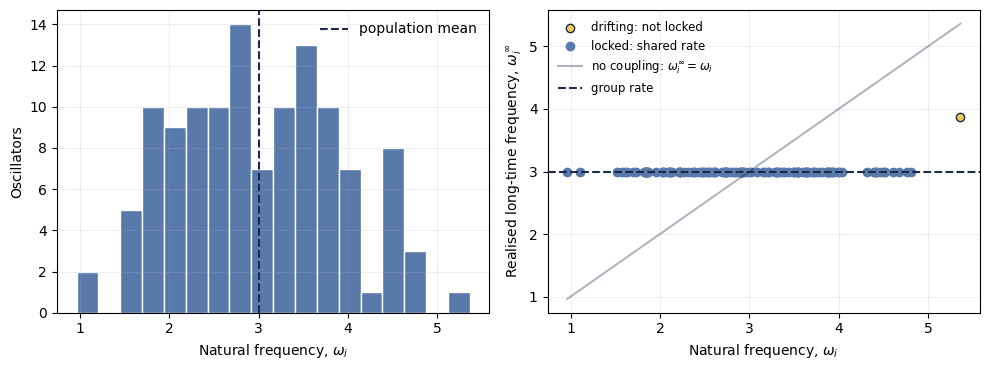

Yellow oscillator: natural rate 5.36; realised rate 3.87.


In [ ]:
def simulate_given_population(
    phases: np.ndarray, frequencies: np.ndarray, coupling: float, dt: float, steps: int
) -> np.ndarray:
    history = np.empty((steps + 1, len(phases)))
    history[0] = phases
    for time in range(1, steps + 1):
        phases = wrap_phase(
            phases + dt * (frequencies + coupling * kuramoto_coupling(phases))
        )
        history[time] = phases
    return history


rng = np.random.default_rng(SEED)
initial_phases, omega = sample_population("broad", 120, rng)
locked_history = simulate_given_population(initial_phases, omega, coupling=2.4, dt=0.05, steps=1200)
unwrapped_tail = np.unwrap(locked_history[-301:], axis=0)
realised_rate = (unwrapped_tail[-1] - unwrapped_tail[0]) / (300 * 0.05)
group_rate = np.median(realised_rate)
locked = np.abs(realised_rate - group_rate) < 0.08

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(omega, bins=18, color=BLUE, edgecolor="white")
axes[0].axvline(omega.mean(), color=INK, ls="--", label="population mean")
axes[0].set(xlabel=r"Natural frequency, $\omega_i$", ylabel="Oscillators")
axes[0].legend(frameon=False)
axes[1].scatter(omega[~locked], realised_rate[~locked], color=YELLOW, edgecolor=INK, label="drifting: not locked")
axes[1].scatter(omega[locked], realised_rate[locked], color=BLUE, label="locked: shared rate")
limits = [min(omega.min(), realised_rate.min()), max(omega.max(), realised_rate.max())]
axes[1].plot(limits, limits, color=INK, alpha=0.35, label=r"no coupling: $\omega_i^\infty=\omega_i$")
axes[1].axhline(group_rate, color=INK, ls="--", label="group rate")
axes[1].set(xlabel=r"Natural frequency, $\omega_i$", ylabel=r"Realised long-time frequency, $\omega_i^\infty$")
axes[1].legend(frameon=False, fontsize=8.5, loc="upper left")
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


drifting_indices = np.flatnonzero(~locked)
if len(drifting_indices):
    highlighted_drifter = int(drifting_indices[np.argmax(omega[drifting_indices])])
    print(
        f"Yellow oscillator: natural rate {omega[highlighted_drifter]:.2f}; "
        f"realised rate {realised_rate[highlighted_drifter]:.2f}."
    )
    display(show_animation(animate_kuramoto_run(
        locked_history,
        dt=0.05,
        highlight_index=highlighted_drifter,
    )))


## Let the interaction network evolve
So far, the interaction network has been fixed and complete. In many systems the state also changes who interacts: agreement can strengthen a connection, disagreement can break one, or spatial motion can create and remove neighbours. This creates an **adaptive network**: oscillator states change the network, and the network changes the oscillator states.

Two oscillators are connected when the adjacency matrix has $A_{ij}=1$; the corresponding edge is drawn. The initial graph is sparse. Each possible pair is connected independently with probability $p=\langle k\rangle/(N-1)$, giving expected mean degree $\langle k\rangle$. Connectivity is therefore a modelled relationship, not a consequence of the nodes being close on the page.

At each rewiring event, the code removes only one existing edge and adds only one absent edge. Removal is sampled from the 20% of existing edges with the largest phase differences; addition is sampled from the 20% of absent pairs with the smallest differences. The edge count stays fixed. This is a partial, stochastic rewiring rule, so two nearby phases are not automatically connected and the graph does not become a complete graph of similar oscillators.

The paired display shows the same graph in two layouts. Fixed node positions make changed edges easier to trace. In the phase layout, the angle of each node is its phase. Movement there is movement through phase space, not through a physical domain. Node colour also records phase.

> **Modelling decision:** What process should create or remove a connection in the system you want to represent?


In [ ]:
def random_adjacency(n: int, mean_degree: int, rng: np.random.Generator) -> np.ndarray:
    probability = mean_degree / (n - 1)
    upper = rng.random((n, n)) < probability
    upper = np.triu(upper, 1)
    return (upper | upper.T).astype(int)


def network_coupling(phases: np.ndarray, adjacency: np.ndarray) -> np.ndarray:
    pairwise = np.sin(phases[None, :] - phases[:, None])
    degree = adjacency.sum(axis=1)
    return (adjacency * pairwise).sum(axis=1) / np.maximum(degree, 1)


def rewire_by_phase_similarity(
    adjacency: np.ndarray, phases: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    adjacency = adjacency.copy()
    phase_gap = np.abs(np.angle(np.exp(1j * (phases[:, None] - phases[None, :]))))
    existing = np.argwhere(np.triu(adjacency, 1) == 1)
    available = np.argwhere(np.triu(1 - adjacency - np.eye(len(phases), dtype=int), 1) == 1)
    if len(existing) == 0 or len(available) == 0:
        return adjacency
    remove_candidates = existing[phase_gap[existing[:, 0], existing[:, 1]] >= np.quantile(
        phase_gap[existing[:, 0], existing[:, 1]], 0.8
    )]
    add_candidates = available[phase_gap[available[:, 0], available[:, 1]] <= np.quantile(
        phase_gap[available[:, 0], available[:, 1]], 0.2
    )]
    i, j = remove_candidates[rng.integers(len(remove_candidates))]
    u, v = add_candidates[rng.integers(len(add_candidates))]
    adjacency[i, j] = adjacency[j, i] = 0
    adjacency[u, v] = adjacency[v, u] = 1
    return adjacency


def simulate_adaptive_kuramoto(
    n=36, coupling=2.2, frequency_mean=3.0, frequency_sd=0.65, mean_degree=5,
    dt=0.02, steps=1400, rewire_every=5, store_every=4, seed=SEED, progress=True
):
    rng = np.random.default_rng(seed)
    phases = rng.uniform(-np.pi, np.pi, n)
    frequency_offsets = rng.normal(0.0, frequency_sd, n)
    frequency_offsets -= frequency_offsets.mean()
    frequencies = frequency_mean + frequency_offsets
    adjacency = random_adjacency(n, mean_degree, rng)
    phase_frames, edge_frames, coherence_history, frame_times = [], [], [], []
    step_values = range(steps + 1)
    if progress:
        step_values = tqdm(step_values, total=steps + 1, desc="Adaptive network", leave=False)
    for step in step_values:
        if step % store_every == 0:
            phase_frames.append(phases.copy())
            edge_frames.append(np.argwhere(np.triu(adjacency, 1) == 1).tolist())
            coherence_history.append(np.abs(np.mean(np.exp(1j * phases))))
            frame_times.append(step * dt)
        phases = wrap_phase(phases + dt * (frequencies + coupling * network_coupling(phases, adjacency)))
        if step > 0 and step % rewire_every == 0:
            adjacency = rewire_by_phase_similarity(adjacency, phases, rng)
    return (np.array(phase_frames), edge_frames, np.array(coherence_history),
            frequencies, np.array(frame_times))


adaptive_phases, adaptive_edges, adaptive_r, adaptive_omega, adaptive_time = simulate_adaptive_kuramoto(
    n=choose(36, 24), steps=choose(1400, 500), store_every=choose(4, 3)
)
print(f"Stored {len(adaptive_phases)} network frames; mean degree remains approximately {2 * len(adaptive_edges[-1]) / len(adaptive_omega):.1f}.")


In [ ]:
def animate_adaptive_network(phase_frames, edge_frames, coherence_history, frame_times, interval=70):
    display_step = max(1, len(phase_frames) // 220)
    display_frames = np.arange(0, len(phase_frames), display_step)
    n = phase_frames.shape[1]
    fixed_angles = 2 * np.pi * np.arange(n) / n
    fixed_xy = np.column_stack((np.cos(fixed_angles), np.sin(fixed_angles)))
    colours = plt.get_cmap("cividis")

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4), layout="constrained")
    for ax, title in zip(axes, ("Fixed layout", "Phase layout")):
        ax.set(title=title, xlim=(-1.15, 1.15), ylim=(-1.15, 1.15), aspect="equal")
        ax.axis("off")
    angle = np.linspace(0, 2 * np.pi, 300)
    axes[1].plot(np.cos(angle), np.sin(angle), color="#D9DFEA", lw=1.2)
    time_text = fig.text(0.5, 0.02, "", ha="center", color=INK)

    def update(display_index):
        k = display_frames[display_index]
        for ax in axes:
            for artist in list(ax.collections) + list(ax.lines[1:] if ax is axes[1] else ax.lines):
                artist.remove()
        phase_xy = np.column_stack((np.cos(phase_frames[k]), np.sin(phase_frames[k])))
        scaled = (phase_frames[k] + np.pi) / (2 * np.pi)
        for ax, xy in zip(axes, (fixed_xy, phase_xy)):
            for i, j in edge_frames[k]:
                ax.plot(xy[[i, j], 0], xy[[i, j], 1], color=BLUE, alpha=0.20, lw=0.7, zorder=1)
            ax.scatter(xy[:, 0], xy[:, 1], c=scaled, cmap="cividis", vmin=0, vmax=1,
                       s=28, edgecolor=INK, linewidth=0.4, zorder=2)
        time_text.set_text(f"$t={frame_times[k]:.1f}$; global coherence $r={coherence_history[k]:.2f}$")
        return []

    anim = animation.FuncAnimation(fig, update, frames=len(display_frames), interval=interval, blit=False)
    return anim


display(show_animation(animate_adaptive_network(
    adaptive_phases, adaptive_edges, adaptive_r, adaptive_time
)))


### Show the clocks rather than the phase value
The coloured animation exposes the hidden phase state. A second representation shows what an observer might actually see: fixed grey nodes briefly flash as their clocks pass 12 o'clock.

For this display we use a separate, strongly coupled all-to-all population. The adaptive network above need not settle into one phase-locked group, so reusing it here would not guarantee synchronised flashes. This animation is retained because it changes the observable, not because it has a different player.


In [ ]:
flash_parameters = KuramotoParameters(
    n_oscillators=36, coupling=4.5, dt=0.02, frequency_mean=3.0, frequency_sd=0.45
)
flash_history, _ = simulate_kuramoto(
    flash_parameters, steps=choose(1400, 500), seed=SEED,
    progress=True, description="Flashing population",
)


def animate_flashing_population(phase_frames, dt, interval=65):
    display_step = max(1, min(len(phase_frames) // 280, round(0.08 / dt)))
    display_frames = np.arange(0, len(phase_frames), display_step)
    n = phase_frames.shape[1]
    fixed_angles = 2 * np.pi * np.arange(n) / n
    xy = np.column_stack((np.cos(fixed_angles), np.sin(fixed_angles)))

    fig, ax = plt.subplots(figsize=(4.0, 3.5), layout="constrained")
    ax.set(title="Observed flashes", xlim=(-1.15, 1.15), ylim=(-1.15, 1.15), aspect="equal")
    ax.axis("off")
    time_text = ax.text(0, -1.1, "", ha="center", va="top", color=INK)

    def update(display_index):
        k = display_frames[display_index]
        for artist in list(ax.collections) + list(ax.lines):
            artist.remove()
        flash_gap = np.abs(np.angle(np.exp(1j * (phase_frames[k] - np.pi / 2))))
        flashing = flash_gap < 0.18
        node_colours = np.where(flashing, YELLOW, "#B9C0CB")
        node_sizes = np.where(flashing, 62, 30)
        ax.scatter(xy[:, 0], xy[:, 1], c=node_colours, s=node_sizes,
                   edgecolor=INK, linewidth=0.5, zorder=2)
        coherence = np.abs(np.mean(np.exp(1j * phase_frames[k])))
        time_text.set_text(f"$t={k * dt:.1f}$; coherence $r={coherence:.2f}$")
        return []

    anim = animation.FuncAnimation(fig, update, frames=len(display_frames), interval=interval, blit=False)
    return anim


display(show_animation(animate_flashing_population(flash_history, flash_parameters.dt)))


### Analyse the network as well as the phases
The animation and the diagnostics below come from the same stored run.

Global coherence $r$ combines every phase vector. If two internally aligned groups sit on different parts of the phase circle, their vectors partly cancel and $r$ can rise and fall even though most connected neighbours agree.

The **phase-similar edge fraction** is the proportion of the edges that currently exist whose endpoints differ by less than $\pi/6$. It says whether linked oscillators have similar phases; it does not count how many possible edges exist. It can approach one while old edges continue to be replaced because the model keeps the edge count fixed.

The final panel records the fraction of the original edges still present. A falling curve confirms that the graph is being rewired. A plateau would indicate that the network has become stable under this particular rewiring rule.


In [ ]:
similar_edge_fraction = []
initial_edges = {tuple(edge) for edge in adaptive_edges[0]}
initial_edge_retention = []

for phases, edges in zip(adaptive_phases, adaptive_edges):
    gaps = [abs(np.angle(np.exp(1j * (phases[i] - phases[j])))) for i, j in edges]
    similar_edge_fraction.append(np.mean(np.asarray(gaps) < np.pi / 6))
    current_edges = {tuple(edge) for edge in edges}
    initial_edge_retention.append(len(initial_edges & current_edges) / len(initial_edges))

frame_time = adaptive_time
frame_r = adaptive_r

fig, axes = plt.subplots(1, 3, figsize=(11, 3.25), layout="constrained")
axes[0].plot(frame_time, frame_r, color=INK)
axes[0].set(xlabel="Simulation time", ylabel="Global coherence, $r$", ylim=(-0.03, 1.03))
axes[1].plot(frame_time, similar_edge_fraction, color=BLUE)
axes[1].set(xlabel="Simulation time", ylabel="Phase-similar edge fraction", ylim=(-0.03, 1.03))
axes[2].plot(frame_time, initial_edge_retention, color="#DF6338")
axes[2].set(xlabel="Simulation time", ylabel="Original edges retained", ylim=(-0.03, 1.03))
for ax in axes:
    ax.grid(alpha=0.2)
plt.show()


#### Two coherent groups can still cancel globally
A low global coherence does not always mean that every oscillator is disordered. Imagine two internally coherent groups on opposite sides of the phase circle. Each group has coherence one, but their two mean vectors partly or completely cancel in the population-wide average. This is a cluster state, not a chimera: both groups are coherent, whereas a chimera combines coherent and incoherent subsets.

> **Discuss:** If the global value of $r$ falls while the phase-similar edge fraction remains high, what would you inspect next? Which summary would distinguish two coherent groups from one disordered population?

This is an interpretation checkpoint rather than another required simulation. If this structure matters for a project, calculate coherence separately within each detected group and compare it with the global value.


# Extend


## Further investigation
The workshop has already changed the natural-frequency distribution and allowed the interaction network to rewire. Other sensible directions include:

- changing the shape or width of the natural-frequency distribution;
- assigning different coupling strengths to different oscillators;
- replacing all-to-all coupling with a fixed local, sparse or modular network;
- changing the rewiring rule or its time scale;
- allowing oscillators to move in physical space, as in a swarmalator model.

Choose one direction and turn it into your own investigation. State the question, the one modelling assumption you will change, what you will keep fixed, what you will measure, and what comparison would let you answer the question. Do not change several parts of the model at once.


# Exit ticket
Record:

1. the distinction between phase coincidence and synchronisation;
2. one test that checked the implementation;
3. one conclusion supported by a distribution or ensemble;
4. one modelling assumption encoded by the rewiring rule;
5. the investigation you designed above, including the comparison you would make.
